# Lowlevel Simulation

In [1]:
from Go2Py.sim.mujoco import Go2Sim
import numpy as np

In [2]:
robot = Go2Sim(mode='lowlevel')

Failed to load plugin 'libdecor-gtk.so': failed to init
No plugins found, falling back on no decorations
/home/aidan/Desktop/ENGR6010_Exam1/q3_apps/.venv/lib/python3.10/site-packages/glfw/__init__.py:917: GLFWError: (65548) b'Wayland: The platform does not provide the window position'
  warnings.warn(message, GLFWError)


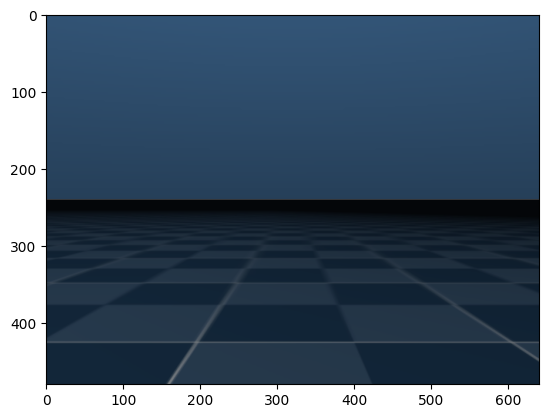

In [3]:
import matplotlib.pyplot as plt
camera_state = robot.getCameraState()
plt.imshow(camera_state['rgb'])

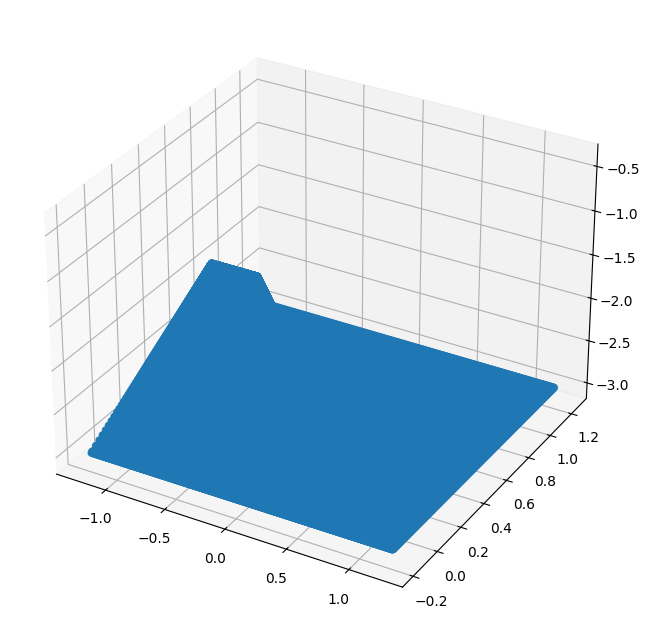

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import proj3d

state = robot.getCameraState(get_pointcloud=True)
pcd = state['pointcloud']

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(pcd[:,0], pcd[:,1], pcd[:,2])
plt.show()


In [5]:
robot.getJointStates()

{'q': array([-0.02430817,  1.26248408, -2.82534656,  0.04485518,  1.25052281,
        -2.79139806, -0.30687499,  1.28300722, -2.8203912 ,  0.26473361,
         1.29374278, -2.83947022]),
 'dq': array([ 0.21118207, -0.00341626,  0.93705654, -0.25373598, -0.00378257,
         0.62815678, -0.20412863,  0.05436351,  0.88507564,  0.23486958,
         0.05996461,  1.05861611]),
 'tau_est': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])}

In [6]:
import mujoco
import time
import cv2
camera_dt = 1./60.
robot.standUpReset()
start_time = time.time()
step_counter = 0
while time.time()-start_time < 10:
    state = robot.getJointStates()
    tau = 20*np.eye(12)@(robot.q0 - state['q']).reshape(12,1)
    robot.setCommands(np.zeros(12), np.zeros(12), np.zeros(12), np.zeros(12), tau)
    robot.step()
    if step_counter%(camera_dt//robot.dt)==0:
        camera_state = robot.getCameraState()
        cv2.imshow('rgb', cv2.cvtColor(camera_state['rgb'], cv2.COLOR_BGR2RGB))
        cv2.waitKey(1)
    step_counter+=1
cv2.destroyAllWindows()

QFontDatabase: Cannot find font directory /home/aidan/Desktop/ENGR6010_Exam1/q3_apps/.venv/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/aidan/Desktop/ENGR6010_Exam1/q3_apps/.venv/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/aidan/Desktop/ENGR6010_Exam1/q3_apps/.venv/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/aidan/Desktop/ENGR6010_Exam1/q3_apps/.venv/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for ex

# Highlevel Simulation

In [7]:
from Go2Py.sim.mujoco import Go2Sim
import numpy as np

In [8]:
robot = Go2Sim(mode='highlevel')
robot.standUpReset()

/home/aidan/Desktop/ENGR6010_Exam1/q3_apps/.venv/lib/python3.10/site-packages/glfw/__init__.py:917: GLFWError: (65548) b'Wayland: The platform does not provide the window position'
  warnings.warn(message, GLFWError)


p_gains: [20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20.]


In [9]:
import mujoco
import time
import cv2
camera_dt = 1./60.
robot.standUpReset()
start_time = time.time()
step_counter = 0
while time.time()-start_time < 10:
    robot.step(0,0,0., step_height=0,kp=[2, 0.5, 0.5], ki=[0.02, 0.01, 0.01])
    if step_counter%(camera_dt//robot.dt)==0:
        camera_state = robot.getCameraState()
        cv2.imshow('rgb', cv2.cvtColor(camera_state['rgb'], cv2.COLOR_BGR2RGB))
        cv2.waitKey(1)
    step_counter+=1
cv2.destroyAllWindows()

In [10]:
robot.getLaserScan()

{'pcd': array([[-28.89032689,   7.52757714,   0.        ],
        [-28.6812632 ,   7.28528492,   0.        ],
        [-28.47584088,   7.04721284,   0.        ],
        [-28.27395054,   6.8132341 ,   0.        ],
        [-28.075487  ,   6.58322681,   0.        ],
        [-27.88034915,   6.35707381,   0.        ],
        [-27.68843974,   6.13466236,   0.        ],
        [-27.49966517,   5.91588402,   0.        ],
        [-27.31393537,   5.70063436,   0.        ],
        [-27.13116357,   5.48881286,   0.        ],
        [-26.9512662 ,   5.28032266,   0.        ],
        [-26.77416273,   5.07507041,   0.        ],
        [-26.59977552,   4.87296614,   0.        ],
        [-26.42802969,   4.67392307,   0.        ],
        [-26.25885302,   4.4778575 ,   0.        ],
        [-26.0921758 ,   4.28468865,   0.        ],
        [-25.92793075,   4.09433853,   0.        ],
        [-25.76605289,   3.90673185,   0.        ],
        [-25.60647947,   3.72179587,   0.        ],
     

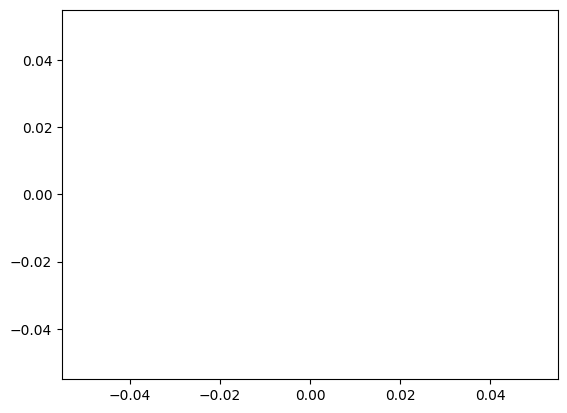

In [11]:
import matplotlib.pyplot as plt
lidar = robot.getLaserScan(max_range=3.)
idx = np.where(lidar['dist']!=-1)[0]
plt.plot(lidar['dist'][idx])